<a href="https://colab.research.google.com/github/drpetros11111/The-Complete-Neural-Networks-Bootcamp-Theory-Applications/blob/Training/neural_net_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets

In [2]:
X,y = sklearn.datasets.make_moons(200, noise = 0.15)

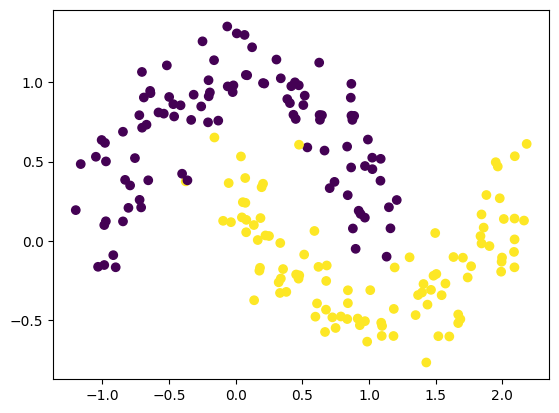

In [3]:
plt.scatter(X[:,0],X[:,1], c=y)

#c=y:
By setting c=y, you are telling the plt.scatter function to use the values in y to determine the color of each corresponding point in the plot.

# Plotting a Scatter Plot


---
----

##plt.scatter():
This is the Matplotlib function used to create a scatter plot.

------------------
##X[:,0]:
This represents the data for the x-axis of the scatter plot. Let's break it down further:

###X:
This likely refers to a NumPy array or a pandas DataFrame containing your data.

###[:,0]:
This is slicing notation used to select all rows ([:]) and the first column (0) of the data.

So, it extracts the values from the first column of X and uses them as the x-coordinates of the points in the scatter plot.

-------------------------
##X[:,1]:
This is similar to X[:,0], but it selects the second column (1) of the data.

These values are used as the y-coordinates of the points in the scatter plot.

----------------------
###c=y:
This argument specifies the color of the points in the scatter plot.

####c:
Stands for "color".

####y:
This likely refers to another array or list that contains values corresponding to each data point in X.

These values are used to determine the color of each point.

Different values in y will result in different colors being assigned to the points.

This is often used to visually distinguish between different classes or categories in your data.
In simpler terms:

Imagine you have a dataset with two features (represented by the columns of X) and you want to see how these features relate to each other. This code would:

Take the values from the first column of your data and use them as the x-coordinates of points on a graph.

Take the values from the second column of your data and use them as the y-coordinates of those points.

Plot those points on a graph, where the color of each point is determined by the corresponding value in y.

-------------------------
##Example:

If X contains data about the height and weight of people, and y contains their gender (0 for male, 1 for female), then the scatter plot would show the relationship between height and weight, with points colored differently for males and females.

In [4]:
print(X.shape, y.shape)

(200, 2) (200,)


In [6]:
input_neurons = 2
output_neurons = 2
samples = X.shape[0]
learning_rate = 0.001
lambda_reg = 0.01

# Lamda Reguralization Function
In the provided code snippet, lambda_reg is used for regularization in machine learning models.

Regularization is a technique used to prevent overfitting by adding a penalty to the loss function based on the magnitude of the model's parameters.


Regularization helps to prevent overfitting by adding a regularization term to the loss function. There are different types of regularization, but the most common are L1 (Lasso) and L2 (Ridge) regularization:

L1 Regularization (Lasso): Adds the sum of the absolute values of the coefficients (weights) as a penalty term.

L2 Regularization (Ridge): Adds the sum of the squared values of the coefficients (weights) as a penalty term.

-----------
##Example
If you are using L2 regularization, the loss function L is modified as follows:

$$𝐿
=
𝐿
original
+
𝜆
∑
𝑖
𝑤
𝑖
^2
$$
​


Where:

$$𝐿$$
original
L
original
​
  is the original loss (e.g., cross-entropy loss).
$$𝜆$$
λ is the regularization parameter (lambda_reg in the code).
$$𝑤
𝑖
$$
​
  are the model parameters (weights).

This regularization term penalizes large weights and encourages the model to keep the weights smaller, which can help in generalizing better to new data.

----
Integrating Regularization into Your Training Loop:

In a typical training loop, you would add the regularization term to your loss function before performing backpropagation. Here's a simplified example:

    for epoch in range(num_epochs):
       optimizer.zero_grad()
       output = network(X)
       loss = loss_function(output, y)

       # Adding L2 regularization term
       l2_reg = lambda_reg * sum(param.pow(2).sum() for param in network.parameters())
       loss += l2_reg

       loss.backward()
       optimizer.step()

In this example:

loss_function(output, y) computes the original loss.

lambda_reg * sum(param.pow(2).sum() for param in network.parameters()) computes the L2 regularization term.

loss += l2_reg adds the regularization term to the original loss.

The rest of the code performs backpropagation and updates the model parameters.

In [ ]:
def retreive(model_dict):
    W1 = model_dict['W1']
    b1 = model_dict['b1']
    W2 = model_dict['W2']
    b2 = model_dict['b2']
    return W1, b1, W2, b2

# Extract Weights & Biases
This function is designed to extract the weights and biases from a dictionary representing a neural network model.


---
------

Breakdown:

##def retrieve(model_dict)::

This line defines the function named retrieve, which takes one argument:

##model_dict:
A dictionary that is expected to contain the weights and biases of the neural network model.

##W1 = model_dict['W1']:
This line retrieves the value associated with the key 'W1' from the model_dict and assigns it to the variable W1.

This value typically represents the weights of the first layer of the neural network.

##b1 = model_dict['b1']:
Similar to the previous line, this retrieves the value associated with the key 'b1' and assigns it to b1, representing the biases of the first layer.

##W2 = model_dict['W2']:
This line retrieves the weights of the second layer (likely the output layer) and assigns them to W2.

##b2 = model_dict['b2']:
This line retrieves the biases of the second layer and assigns them to b2.

##return W1, b1, W2, b2:
This line returns the extracted weights and biases as a tuple.

This allows other parts of the code to easily access these values for use in calculations or updates during training.

----------------------------------------
#In essence,
the retrieve function acts as a helper function to conveniently access the parameters of a neural network model stored within a dictionary.

It simplifies the process of retrieving these values, making the code more organized and readable.

---------------------------
#Example:


# Assume model_dict is defined elsewhere
W1, b1, W2, b2 = retrieve(model_dict)

# Now you can use W1, b1, W2, and b2 in your calculations

This function promotes code reusability and clarity by encapsulating the logic for retrieving model parameters, allowing you to focus on other aspects of your neural network implementation.

-----------------
--------------------------
#Note: The dictionary of weights and biases

Used in the code (model_dict) is not inherently defined or automatically created.

It needs to be created a priori, meaning before using the retrieve function.

##Reasoning:

The retrieve function assumes the existence of model_dict with specific keys ('W1', 'b1', 'W2', 'b2') that hold the weight and bias values.

If model_dict is not created and populated with these keys and values before calling retrieve, the function will raise a KeyError.

##How it's typically created:

##Initialization:
You usually create model_dict and initialize the weights and biases with random or specific values before training the neural network.

This is often done using a separate function or directly assigning values.

##Training:
During the training process, the weights and biases in model_dict are updated iteratively to optimize the network's performance.

Example:


# Initialization
model_dict = {
    'W1': np.random.randn(input_size, hidden_size),
    'b1': np.zeros((1, hidden_size)),
    'W2': np.random.randn(hidden_size, output_size),
    'b2': np.zeros((1, output_size))
}

# ... (training process) ...

# Retrieving weights and biases
W1, b1, W2, b2 = retrieve(model_dict)
Use code with caution.

In this example, model_dict is created and initialized before training.

The retrieve function is then used to access the updated weights and biases after training.

Therefore, the dictionary of weights and biases is not an intrinsic part of the language or framework.

It's a structure that you as the developer need to create and manage to store and access the parameters of your neural network model.

In [ ]:
def forward(x, model_dict):
    W1, b1, W2, b2 = retreive(model_dict)
    z1 = X.dot(W1) + b1
    a1 = np.tanh(z1)
    z2 = a1.dot(W2) + b2
    exp_scores = np.exp(z2)
    softmax = exp_scores / np.sum(exp_scores, axis = 1, keepdims = True)
    return z1, a1, softmax

# Forward Propagation Function
This code snippet defines a forward propagation function for a simple neural network with one hidden layer.

The function forward takes an input matrix x and a dictionary model_dict containing the model's parameters, and it returns the intermediate and final outputs of the network.

-----
## Retrieving Model Parameters:

    W1, b1, W2, b2 = retreive(model_dict)

This line retrieves the weights and biases of the network from model_dict.

###Specifically:

W1 and b1 are the weights and biases for the first (hidden) layer.

W2 and b2 are the weights and biases for the second (output) layer.

-----
##First Layer Computations:

    z1 = x.dot(W1) + b1
    a1 = np.tanh(z1)
    z1 = x.dot(W1) + b1

This computes the linear combination of the input x and the weights W1, adding the bias b1.

The result is the input to the activation function of the first layer.

------
    a1 = np.tanh(z1)

This applies the hyperbolic tangent activation function to z1, resulting in the activations of the first layer.

------
##Second Layer Computations:

    z2 = a1.dot(W2) + b2
    z2 = a1.dot(W2) + b2

This computes the linear combination of the activations from the first layer a1 and the weights W2, adding the bias b2.

The result is the input to the activation function of the second layer.

----
##Softmax Output Computation

    exp_scores = np.exp(z2)

    softmax = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


###exp_scores = np.exp(z2)

This exponentiates z2 element-wise. The exponential function is used here as part of the softmax computation.

Applying the Exponential Function:
We apply the exponential function to each element of the logits:

Let's calculate the exponential of each element in z2:

$$exp
⁡
(
2.0
)
=
𝑒
2
≈
7.389$$

$$exp(2.0)=e
2
 ≈7.389$$

$$exp
⁡
(
1.0
)
=
𝑒
1
≈
2.718$$

$$exp(1.0)=e
1
 ≈2.718
exp
⁡
(
0.1
)
=
𝑒
0.1
≈
1.105$$

$$exp(0.1)=e
0.1
 ≈1.105$$
So, exp_scores will be:

    exp_scores = np.array([7.389, 2.718, 1.105])

##Contextualizing with the Softmax Function:
The softmax function involves normalizing these exponentiated scores so that they sum to 1.

This is done by dividing each exponentiated score by the sum of all exponentiated scores:

    softmax = exp_scores / np.sum(exp_scores)


Let's calculate the sum of exp_scores:

$$Sum =
7.389
+
2.718
+
1.105
=
11.212$$

Now, normalize each exponentiated score:

##Softmax of class 1:
$$7.389/
11.212
≈
0.659$$

$$11.212
7.389
​
 ≈0.659$$

##Softmax of class 2:
$$2.718/
11.212
≈
0.242
11.212
2.718
​
 ≈0.242$$

##Softmax of class 3:
$$1.105/
11.212
≈
0.099
11.212
1.105
​
 ≈0.099$$

The final probabilities (softmax output) will be:

    softmax = np.array([0.659, 0.242, 0.099])


###softmax = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

This normalizes the exponentiated scores to obtain the softmax probabilities. The softmax function ensures that the output probabilities sum to 1 for each input sample.

-----
Return Values:

    return z1, a1, softmax

The function returns three values:

z1: The linear combination before the activation function in the first layer.

a1: The activations of the first layer.
softmax: The final output probabilities from the softmax function.
------

##Full Code Context
To fully understand the snippet, let's assume the presence of the retreive function and a hypothetical example of model_dict:

#Example Model Dictionary and Retrieve Function

    def retreive(model_dict):
       W1 = model_dict['W1']
       b1 = model_dict['b1']
       W2 = model_dict['W2']
       b2 = model_dict['b2']
       return W1, b1, W2, b2

    model_dict = {
       'W1': np.random.randn(input_size, hidden_size),
       'b1': np.random.randn(1, hidden_size),
       'W2': np.random.randn(hidden_size, output_size),
      'b2': np.random.randn(1, output_size)
   }

##The retrieve function relies on it:
The retrieve function is designed to fetch weights and biases from a dictionary with specific keys ('W1', 'b1', 'W2', 'b2').

If model_dict doesn't exist with these keys when retrieve is called, you'll get an error (a KeyError because the keys are missing).

##It holds the model's parameters:
The weights and biases are the essential parameters of a neural network.

They determine how the network processes information and makes predictions. The model_dict acts as a container to store and organize these parameters.

##How it's Created and Used:

##Initialization:

Create the dictionary: You start by creating an empty dictionary and assigning it to the variable model_dict.

##Initialize weights and biases:

You then add entries to the dictionary, using the keys 'W1', 'b1', 'W2', 'b2' to represent the weights and biases of different layers in your neural network.

These values are often initialized randomly or with specific values using functions like np.random.randn or np.zeros.

##Training:

##Updating parameters:

During the training process, your neural network learns by adjusting its weights and biases.

These updates are stored back into the model_dict.

##Accessing parameters:
The retrieve function is used within the training loop to conveniently access the current values of the weights and biases from model_dict.

##After Training:

##Storing the trained model:

The model_dict now contains the trained weights and biases. You can save this dictionary to disk to reuse your trained model later.

##Making predictions:
When you want to use the trained model to make predictions on new data, you load the model_dict and pass it to functions that need the weights and biases (like the predict function).

##In Summary:

The model_dict is a custom dictionary that you create to store and manage the weights and biases of your neural network.

It's created before training, initialized with starting values, updated during training, and used for making predictions after training.

This approach helps keep your neural network code organized and makes it easier to work with the model's parameters.

-----   
#Example Usage

    x = np.random.randn(num_samples, input_size)
    z1, a1, softmax = forward(x, model_dict)
    print(softmax)

In this example:

x is the input data matrix with num_samples rows and input_size columns.
model_dict contains randomly initialized weights and biases.

The forward function computes the forward pass, producing the intermediate and final outputs of the network.

This is a straightforward implementation of a forward pass in a neural network with one hidden layer, using the tanh activation function and softmax output.

In [7]:
def loss(softmax, y, model_dict):
    W1, b1, W2, b2 = retreive(model_dict)
    m = np.zeros(200)
    for i,correct_index in enumerate(y):
        predicted = softmax[i][correct_index]
        m[i] = predicted
    log_prob = -np.log(m)
    loss = np.sum(log_prob)
    reg_loss = lambda_reg / 2 * (np.sum(np.square(W1)) + np.sum(np.square(W2)))
    loss+= reg_loss
    return float(loss / y.shape[0])

# Loss Function
The loss function calculates the loss of a neural network with a softmax output, given the true labels. It also includes a regularization term to prevent overfitting.

-----
## Function Parameters
## softmax

The predicted probabilities from the softmax function, a 2D array where each row corresponds to the predicted probability distribution for a sample.

##y

The true labels, an array where each element is the correct class index for a corresponding sample.

##model_dict

A dictionary containing the model parameters (weights and biases).

-----
#Steps in the Function
##Retrieve Model Parameters:

    W1, b1, W2, b2 = retreive(model_dict)

This line retrieves the weights and biases from model_dict.

##Initialize Array for Correct Class Probabilities:

    m = np.zeros(200)

An array m of zeros with the same length as the number of samples is initialized.

This will store the predicted probabilities for the correct classes.

##Extract Probabilities for Correct Classes:

    for i, correct_index in enumerate(y):
       predicted = softmax[i][correct_index]
       m[i] = predicted

This loop iterates over each sample and its true label (correct_index).

It extracts the probability assigned to the correct class from the softmax output and stores it in m.

The correct_index in each iteration is used to find the predicted probability for the true class label of the current sample.

This probability is then used to calculate the log loss, which measures the model's performance by evaluating how well the predicted probabilities match the true class labels.

In essence, correct_index helps in identifying the relevant probability from the softmax output that corresponds to the true class of each sample, which is crucial for calculating the log loss accurately.

#What the enumerate Command Does
The enumerate function in Python adds a counter to an iterable (like a list, tuple, or string) and returns it as an enumerate object.

This allows you to loop through the iterable and have an automatic counter that provides both the index and the value of each item in the iterable.

##Example:

    fruits = ['apple', 'banana', 'cherry']
    for index, fruit in enumerate(fruits):
    print(index, fruit)

##Output:

0 apple
1 banana
2 cherry

In this example, enumerate(fruits) returns an enumerate object that yields pairs of (index, value) for each item in the fruits list.

Thus, index goes from 0 to 2, and fruit takes on the values 'apple', 'banana', and 'cherry'.


##Compute the Log Probability:

    log_prob = -np.log(m)

This computes the negative logarithm of the probabilities stored in m.

This is the log loss (cross-entropy loss) for the correct class predictions.

##Sum of Log Probabilities:

    loss = np.sum(log_prob)

This sums up all the log probabilities to get the total loss.

##Add Regularization Loss:

    reg_loss = lambda_reg / 2 * (np.sum(np.square(W1)) + np.sum(np.square(W2)))

    loss += reg_loss

This computes the L2 regularization loss for W1 and W2.

The regularization term helps prevent overfitting by penalizing large weights. The term is scaled by lambda_reg / 2.

##Return the Average Loss

    return float(loss / y.shape[0])

Finally, the total loss (including regularization) is divided by the number of samples to get the average loss, which is then returned.

-----
#Example with a Small Dataset
Let's consider an example with 3 samples and 2 classes to make this more concrete.

##Predicted probabilities (softmax):

    softmax = np.array([[0.7, 0.3],
                        [0.2, 0.8],
                        [0.6, 0.4]])

##True labels (y):

    y = np.array([0, 1, 0])

##Model parameters (model_dict):

    model_dict = {
       'W1': np.random.randn(2, 3),
       'b1': np.random.randn(3),
       'W2': np.random.randn(3, 2),
       'b2': np.random.randn(2)
      }
-----     
#The function steps would look like this:

##Retrieve W1, b1, W2, b2 from model_dict.

##Initialize m as an array of zeros with length 3.

##Extract correct class probabilities:

For sample 1: m[0] = 0.7 (probability of class 0)
For sample 2: m[1] = 0.8 (probability of class 1)
For sample 3: m[2] = 0.6 (probability of class 0)

#To calculate the log loss, we focus on the predicted probability of the true class for each sample, not necessarily the higher probability.

The log loss for a single sample is calculated using the probability assigned to the correct class.
##Compute log probabilities:
    log_prob = -np.log([0.7, 0.8, 0.6])

#Generalization to More Than Two Classes:
The approach remains the same for more than two classes. Each entry in the y array should still contain the index of the true class.

For each sample, you extract the predicted probability for the true class and calculate the log loss.

Example with Three Classes:
python
Copy code
softmax = np.array([
    [0.1, 0.7, 0.2],  # Predicted probabilities for Sample 1
    [0.4, 0.4, 0.2],  # Predicted probabilities for Sample 2
    [0.3, 0.2, 0.5]   # Predicted probabilities for Sample 3
])

    y = np.array([1, 0, 2])  # True class indices for each sample

To calculate the log loss:

For Sample 1: predicted_probability = 0.7, so log_loss += -np.log(0.7)

For Sample 2: predicted_probability = 0.4, so log_loss += -np.log(0.4)

For Sample 3: predicted_probability = 0.5, so log_loss += -np.log(0.5)

##Sum these log probabilities and divide by the number of samples to get the average log loss.

##Code Implementation

    log_loss = 0
    for i, correct_index in enumerate(y):
       predicted_probability = softmax[i][correct_index]
       log_loss += -np.log(predicted_probability)
        log_loss /= len(y)
        print("Log Loss:", log_loss)

This method ensures that the log loss is calculated correctly for each sample by using the predicted probability of the true class and then averaging over all samples.

##Sum log probabilities to get the loss.

#Compute regularization loss using lambda_reg.

##Return the average loss.

------------
##Final Code
Here is the complete loss function:

    def loss(softmax, y, model_dict):
       W1, b1, W2, b2 = retreive(model_dict)
       m = np.zeros(len(y))  # Adjusted length to match y
       for i, correct_index in enumerate(y):
          predicted = softmax[i][correct_index]
          m[i] = predicted
          log_prob = -np.log(m)
          loss = np.sum(log_prob)
           lambda_reg = 0.01  # Assuming lambda_reg is defined
           reg_loss = lambda_reg / 2 * (np.sum(np.square(W1)) + np.sum(np.square(W2)))
           loss += reg_loss
      return float(loss / y.shape[0])

This function effectively computes the cross-entropy loss with an L2 regularization term included.

# Optimized Code of the Log Loss Function above


In [ ]:
def loss(softmax, y, model_dict):
    W1, b1, W2, b2 = retrieve(model_dict)
    # Optimized log probability calculation
    correct_logprobs = -np.log(softmax[range(len(y)), y])
    data_loss = np.sum(correct_logprobs)
    # Regularization loss (unchanged)
    reg_loss = (lambda_reg / 2) * (np.sum(np.square(W1)) + np.sum(np.square(W2)))
    loss = data_loss + reg_loss
    return float(loss / len(y))  # Using len(y) for consistency

#Efficiently calculates the negative log probabilities of the correct predictions made by your model.

It's a crucial part of the loss function used to evaluate the model's performance during training.

correct_logprobs = -np.log(softmax[range(len(y)), y]):

______________________

Here's a step-by-step explanation:

softmax:
This is a 2D array containing the predicted probabilities for each class for each sample. Its shape is (number of samples, number of classes).

y: This is a 1D array containing the true class labels for each sample.

len(y): This gets the total number of samples in your dataset.

range(len(y)): This creates a sequence of numbers from 0 to the number of samples minus 1. It essentially represents the indices of the rows in softmax.

softmax[range(len(y)), y]: This is where the magic happens. It uses advanced indexing to select the predicted probabilities for the correct classes.

range(len(y)) provides the row indices (corresponding to each sample).

y provides the column indices (corresponding to the true class label for each sample).

This effectively extracts the probability that the model assigned to the actual correct class for each sample.

np.log(...): This calculates the natural logarithm of the selected probabilities.

-np.log(...): Finally, the negative sign is applied to the log probabilities. This is because we want to minimize the loss, and the negative log likelihood is a common loss function for classification tasks.

In simpler terms:

Imagine you have a model predicting whether an image is a cat or a dog. For each image, the model gives you two probabilities: one for "cat" and one for "dog". The correct_logprobs line is essentially:

Finding the probability that the model assigned to the correct class (cat or dog) for each image.
Taking the logarithm of that probability.
Making it negative.
The resulting values represent the "penalty" or "loss" associated with each prediction. Higher values mean the model was less confident about the correct class, and lower values mean it was more confident.

Why is this important?

Loss calculation: These negative log probabilities are then summed up to calculate the overall loss of the model.
Model training: During training, the model tries to adjust its parameters to minimize this loss, which effectively means improving its ability to predict the correct classes.

In [ ]:
def predict(model_dict, x):
    W1, b1, W2, b2 = retreive(model_dict)
    z1 = x.dot(W1) + b1
    a1 = np.tanh(z1)
    z2 = a1.dot(W2) + b2
    exp_scores = np.exp(z2)
    softmax = exp_scores / np.sum(exp_scores, axis = 1, keepdims = True)   # (200,2)
    return np.argmax(softmax, axis = 1)    # (200,)

# The Predict Function

takes a dictionary of model parameters and a set of input features, and returns the predicted class for each input.

This function performs the forward pass of a neural network to compute the output probabilities for each class, and then selects the class with the highest probability as the predicted class.

-----
#Function Breakdown
##1. Retrieve Model Parameters

    W1, b1, W2, b2 = retrieve(model_dict)

This line extracts the weights (W1 and W2) and biases (b1 and b2) from the model_dict dictionary.

These parameters define the neural network's structure.

------
##2. Compute First Layer (Hidden Layer)

    z1 = x.dot(W1) + b1
    a1 = np.tanh(z1)
    z1 = x.dot(W1) + b1
    
Computes the linear combination of inputs x and weights W1, then adds the bias b1.

    a1 = np.tanh(z1)

Applies the hyperbolic tangent activation function to the result, producing the activations for the hidden layer.

----
##3. Compute Second Layer (Output Layer)

    z2 = a1.dot(W2) + b2
    z2 = a1.dot(W2) + b2
    
Computes the linear combination of hidden layer activations a1 and weights W2, then adds the bias b2.

----
##4. Apply Softmax to Compute Probabilities

    exp_scores = np.exp(z2)
    softmax = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    exp_scores = np.exp(z2)
    
Applies the exponential function to each element in z2. This transforms the values into positive numbers.

    softmax = exp_scores / np.sum(exp_scores, axis=1, keepdims=True):

Normalizes the exponential scores to produce probabilities. The np.sum function sums the exponential scores across classes (specified by axis=1), ensuring that the probabilities for each input sample sum to 1.

-----
##5. Return the Predicted Class

    return np.argmax(softmax, axis=1)

np.argmax(softmax, axis=1)

Finds the index of the highest probability for each input sample. This index corresponds to the predicted class.

------
#Example
Let's go through an example to illustrate how this function works.

##Given Inputs
Assume model_dict contains:
W1: weights for the first layer
b1: biases for the first layer
W2: weights for the second layer
b2: biases for the second layer
x: an input matrix with shape (200, input_neurons)

----
##Steps
###Retrieve Parameters:

    W1, b1, W2, b2 = retrieve(model_dict)

###Compute Hidden Layer Activations:

    z1 = x.dot(W1) + b1  # Linear combination
    a1 = np.tanh(z1)     # Activation function

##Compute Output Layer:

    z2 = a1.dot(W2) + b2  # Linear combination

##Compute Softmax Probabilities:

    exp_scores = np.exp(z2)
    softmax = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

##Return Predicted Class:

    return np.argmax(softmax, axis=1)

----
##Full Function

    def predict(model_dict, x):
       W1, b1, W2, b2 = retrieve(model_dict)
       z1 = x.dot(W1) + b1
       a1 = np.tanh(z1)
       z2 = a1.dot(W2) + b2
       exp_scores = np.exp(z2)
       softmax = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
       return np.argmax(softmax, axis=1)
       
In summary, this function computes the predicted class by performing a forward pass through the neural network, calculating the softmax probabilities, and then selecting the class with the highest probability for each input sample

#**Equations for Backprop**

![backprop](https://user-images.githubusercontent.com/30661597/67566804-3e405980-f75b-11e9-9e19-f3c388745c0a.png)

## $\frac{\partial L}{\partial y_{1}}=-\tilde{y}_{1}\left[\frac{\left(y_{1}\right)^{\prime}}{y_{1}}\right]=-\tilde{y}_{1}\left[\frac{1}{y_{1}}\right]$

## $\frac{\partial y_{1}}{\partial z_{1}}=\frac{\partial}{\partial z_{1}} \cdot \frac{e^{z_{1}}}{e^{z_{1}}+e^{z_{2}}+e^{z_{3}}}$

![der](https://user-images.githubusercontent.com/46392773/56460220-ec94cc00-63d1-11e9-91d1-b4e3c57c81fd.png)


## $\frac{\partial L}{\partial y_{1}} \frac{\partial y_{1}}{\partial z_{1}}=-\tilde{y}_{1}\left[\frac{1}{y_{1}}\right]\frac{\partial y_{1}}{\partial z_{1}}=-\tilde{y}_{1}\left[\frac{y_{1}\left(1-y_{1}\right)}{y_{1}}\right]=-\tilde{y}_{1}\left(1-y_{1}\right)$

Recall that our labels are in the form of a one-hot vector: (ex. If class 1 is correct, then the corresponding label is [1,0], if class 2 is correct, then the corresponding label is [0,1]).

If class one is the actual prediction: $\tilde{y}_{1} = 1 $, then we have:

## $\frac{\partial L}{\partial y_{1}} \frac{\partial y_{1}}{\partial z_{1}} = -1(1-y_{1}) = y_{1} - 1 = \delta_{3}$

## $\delta_{2}=\left(1-\tanh ^{2} z_{1}\right) \circ \delta_{3} W_{2}^{T}$

## $\frac{\partial L}{\partial W_{2}}=a_{1}^{T} \delta_{3}$

## $\frac{\partial L}{\partial b_{2}}=\delta_{3}$

## $\frac{\partial L}{\partial W_{1}}=x^{T} \delta 2$

## $\frac{\partial L}{\partial b_{1}}=\delta 2$

In [ ]:
def backpropagation(x, y, model_dict, epochs):
    for i in range(epochs):
        W1, b1, W2, b2 = retreive(model_dict)
        z1, a1, probs = forward(x, model_dict)    # a1: (200,3), probs: (200,2)
        delta3 = np.copy(probs)
        delta3[range(x.shape[0]), y] -= 1      # (200,2)
        dW2 = (a1.T).dot(delta3)               # (3,2)
        db2 = np.sum(delta3, axis=0, keepdims=True)        # (1,2)
        delta2 = delta3.dot(W2.T) * (1 - np.power(np.tanh(z1), 2))
        dW1 = np.dot(x.T, delta2)
        db1 = np.sum(delta2, axis=0)
        # Add regularization terms
        dW2 += lambda_reg * np.sum(W2)
        dW1 += lambda_reg * np.sum(W1)
        # Update Weights: W = W + (-lr*gradient) = W - lr*gradient
        W1 += -learning_rate * dW1
        b1 += -learning_rate * db1
        W2 += -learning_rate * dW2
        b2 += -learning_rate * db2
        # Update the model dictionary
        model_dict = {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}
        # Print the loss every 50 epochs
        if i%50 == 0:
            print("Loss at epoch {} is: {:.3f}".format(i,loss(probs, y, model_dict)))

    return model_dict


# Backpropagation
This snippet is implementing the backpropagation algorithm for training a simple neural network. Let's break it down step by step to understand how each part contributes to the training process.


---


## Overview
The function backpropagation is designed to optimize the weights and biases of a neural network through multiple epochs using gradient descent. Here’s what each part does:


---


## Function Parameters
x: The input data, likely a 2D array where each row is a data sample.

y: The true labels for the input data, often represented as integers corresponding to classes.

model_dict: A dictionary containing the current state of the model, including the weights (W1, W2) and biases (b1, b2).

epochs: The number of times the entire dataset will be passed through the network for training.


---


##The Training Loop
The main loop runs for a number of iterations equal to epochs. Each iteration corresponds to a single epoch, where the model's weights and biases are updated.

-----
###Retrieve Model Parameters:

    W1, b1, W2, b2 = retreive(model_dict)

This line extracts the weights and biases from model_dict for the current epoch.

----
###Forward Pass:

    z1, a1, probs = forward(x, model_dict)

This computes the forward pass through the network:

z1 is the linear combination of inputs and weights for the first layer.

a1 is the activation output from the first layer (likely using a non-linear function like tanh).

probs represents the probabilities or predictions made by the network for each class (output of the second layer, likely using a softmax function).

------
###Calculate delta3 (Error Term for Output Layer):

    delta3 = np.copy(probs)
    delta3[range(x.shape[0]), y] -= 1

delta3 is the error term for the output layer. It's calculated by subtracting 1 from the probability of the correct class (probs is a 2D array where each row corresponds to a sample, and each column corresponds to a class).

This step effectively computes the gradient of the loss with respect to the output layer's inputs.

-----
##Compute Gradients for W2 and b2:

    dW2 = (a1.T).dot(delta3)
    db2 = np.sum(delta3, axis=0, keepdims=True)
    
#dW2 is the gradient of the loss with respect to the weights of the second layer (W2).

It’s computed by multiplying the transpose of the first layer's activations (a1.T) with delta3.

#db2 is the gradient of the loss with respect to the biases of the second layer. It's calculated by summing delta3 across all samples.

-----
##Backpropagate to Compute delta2 (Error Term for Hidden Layer):

    delta2 = delta3.dot(W2.T) * (1 - np.power(np.tanh(z1), 2))

#delta2 represents the error propagated back to the hidden layer.

It’s computed by multiplying delta3 by the transpose of W2, and then element-wise multiplying by the derivative of the activation function (tanh in this case).

##The derivative of tanh is $$1 - tanh^2(z1)$$

-----
#Compute Gradients for W1 and b1:

    dW1 = np.dot(x.T, delta2)
    db1 = np.sum(delta2, axis=0)

dW1 is the gradient of the loss with respect to the weights of the first layer (W1). It’s computed by multiplying the transpose of the input x with delta2.
db1 is the gradient of the loss with respect to the biases of the first layer. It’s calculated by summing delta2 across all samples.

-----
##Add Regularization:

    dW2 += lambda_reg * np.sum(W2)
    dW1 += lambda_reg * np.sum(W1)

These lines add a regularization term to the gradients.

Regularization helps prevent overfitting by penalizing large weights.

##lambda_reg is a regularization parameter that controls the strength of this penalty.

---------------
##Update Weights and Biases:

    W1 += -learning_rate * dW1
    b1 += -learning_rate * db1
    W2 += -learning_rate * dW2
    b2 += -learning_rate * db2

The weights and biases are updated using gradient descent. The learning rate controls the size of the steps taken during the optimization.

------
##Update the Model Dictionary:

    model_dict = {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}

After updating the weights and biases, the model_dict is updated to reflect the new values.

---------------------------
##Loss Printing:

    if i % 50 == 0:
      print("Loss at epoch {} is: {:.3f}".format(i, loss(probs, y, model_dict)))

##Every 50 epochs, the current loss is printed to monitor the training process.

---
##Final Return

    return model_dict

The function returns the updated model_dict containing the optimized weights and biases after the specified number of epochs.

----------
#Summary
This function implements the core of a training loop for a neural network, including forward propagation, backpropagation, gradient computation, weight updates, and loss monitoring.

The use of regularization and learning rate ensures that the network learns effectively while minimizing the risk of overfitting.

In [ ]:
# Define Initial Weights
def init_network(input_dim, hidden_dim, output_dim):
    model = {}
    # Xavier Initialization
    W1 = np.random.randn(input_dim, hidden_dim) / np.sqrt(input_dim)
    b1 = np.zeros((1, hidden_dim))
    W2 = np.random.randn(hidden_dim, output_dim) / np.sqrt(hidden_dim)
    b2 = np.zeros((1, output_dim))
    model['W1'] = W1
    model['b1'] = b1
    model['W2'] = W2
    model['b2'] = b2
    return model

In [ ]:
def plot_decision_boundary(pred_func):
    """
    Code adopted from: https://github.com/dennybritz/nn-from-scratch
    """
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    h = 0.01
    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    # Predict the function value for the whole gid
    Z = pred_func(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    # Plot the contour and training examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral)
    plt.title("Decision Boundary for hidden layer size 3")

In [ ]:
# Now Let's start the action
model_dict = init_network(input_dim = input_neurons , hidden_dim = 3, output_dim = output_neurons)
model = backpropagation(X, y, model_dict, 1000)
plot_decision_boundary(lambda x: predict(model, x))